In [110]:
# ═══════════════════════════════════════════════════════════════════════════
#  ClaimShield ML  |  Member 2  |  AI Catalyst  |  AI Arena 2026
#  XGBoost Fraud Detection  —  Improved Class-Imbalance Pipeline
# ═══════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import os

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score,
)
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

# ── Try XGBoost; fall back to sklearn GBM if not installed ────────────────
try:
    from xgboost import XGBClassifier
    USING_XGB = True
    print("✅ XGBoost found — using XGBClassifier")
except ImportError:
    from sklearn.ensemble import GradientBoostingClassifier as XGBClassifier
    USING_XGB = False
    print("⚠️  XGBoost not installed — using sklearn GBM as stand-in (swap for prod)")

# ── Try SHAP for explainability ───────────────────────────────────────────
try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print("⚠️  shap not installed — feature importance plot used instead")

warnings.filterwarnings("ignore")
os.makedirs("models", exist_ok=True)
os.makedirs("model_plots", exist_ok=True)
sns.set_theme(style="darkgrid")
print("✅ Libraries loaded")

✅ XGBoost found — using XGBClassifier
✅ Libraries loaded


In [164]:
import pickle
import os

# Create a directory for models if it doesn't exist
os.makedirs('models', exist_ok=True)

# Define the file paths
model_path = 'models/fraud_detection_model.pkl'
scaler_path = 'models/scaler.pkl'

# Save the model
with open(model_path, 'wb') as f:
    pickle.dump(best_refined, f)

# Save the scaler (crucial for future predictions)
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler_final, f)

print(f"✅ Model saved to: {model_path}")
print(f"✅ Scaler saved to: {scaler_path}")

# Show how to load it back
# with open(model_path, 'rb') as f:
#     loaded_model = pickle.load(f)

✅ Model saved to: models/fraud_detection_model.pkl
✅ Scaler saved to: models/scaler.pkl


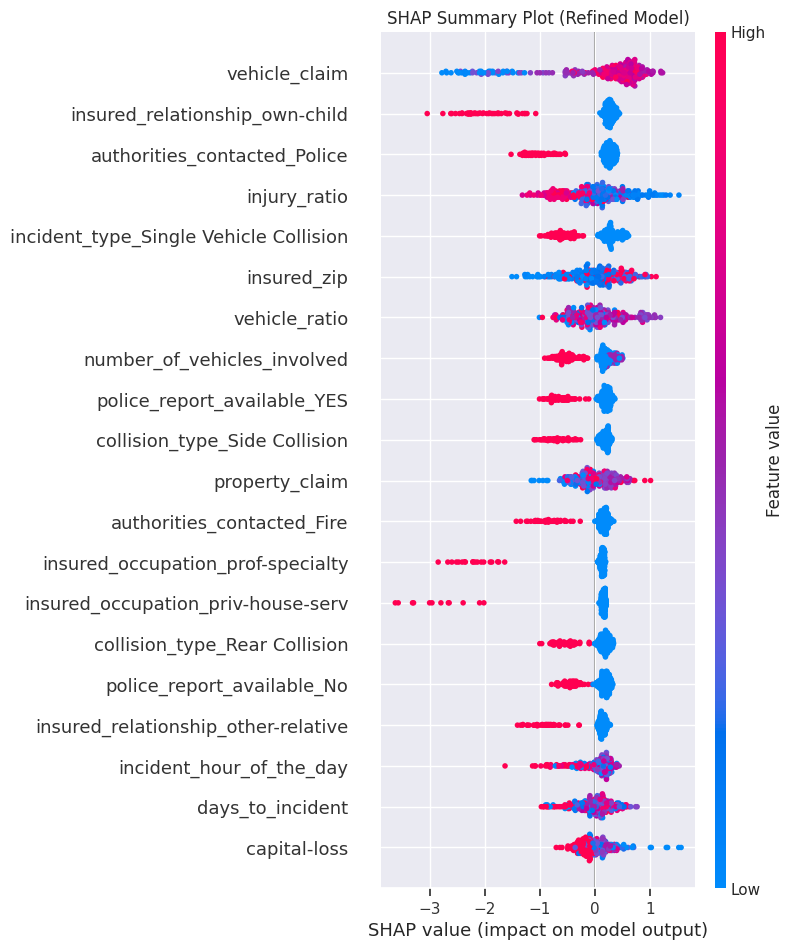

In [163]:
import shap

# Initialize the SHAP explainer for the final refined model
# GradientBoostingClassifier is a tree-based model, so we use TreeExplainer
explainer = shap.TreeExplainer(best_refined)

# Calculate SHAP values for the scaled test set
shap_values = explainer.shap_values(X_test_f)

# Plot the SHAP summary
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sm, feature_names=X_enhanced.columns, show=False)
plt.title("SHAP Summary Plot (Refined Model)")
plt.show()

In [111]:
# ── Load XLSX & convert → CSV ─────────────────────────────────────────────
XLSX_PATH = "/content/Worksheet in Case Study question 2.xlsx"

df_raw = pd.read_excel(XLSX_PATH)
df_csv = df_raw.copy()
for col in df_csv.select_dtypes(include=["datetime64"]).columns:
    df_csv[col] = df_csv[col].dt.strftime("%Y-%m-%d")
df_csv.to_csv("insurance_claims.csv", index=False)
print(f"✅ XLSX converted → insurance_claims.csv  ({df_raw.shape[0]} rows × {df_raw.shape[1]} cols)")

df = df_raw.copy()
print(f"\nClass distribution:")
print(df["fraud_reported"].value_counts())
fraud_pct = (df["fraud_reported"]=="Y").mean()*100
print(f"\n⚠️  Imbalance ratio: {fraud_pct:.1f}% fraud  vs  {100-fraud_pct:.1f}% legit")
print("    → Strategy: balanced_subsample weights + probability threshold tuning")

✅ XLSX converted → insurance_claims.csv  (1000 rows × 39 cols)

Class distribution:
fraud_reported
N    753
Y    247
Name: count, dtype: int64

⚠️  Imbalance ratio: 24.7% fraud  vs  75.3% legit
    → Strategy: balanced_subsample weights + probability threshold tuning


In [112]:
df.isnull().sum()

,0
months_as_customer,0
age,0
policy_number,0
policy_bind_date,0
policy_state,0
policy_csl,0
policy_deductable,0
policy_annual_premium,0
umbrella_limit,0
insured_zip,0


In [113]:
df['policy_number'].nunique()

1000

In [114]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
995,False
996,False
997,False
998,False


In [115]:
df1 = df.drop(columns=['policy_number', 'policy_bind_date', 'policy_state', 'policy_csl', 'policy_deductable', 'policy_annual_premium'], axis=1)

In [116]:
df2 = df1.drop(columns=['incident_date', 'incident_city', 'incident_state'], axis=1)
df2

,months_as_customer,age,umbrella_limit,insured_zip,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,capital-gains,...,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported
0,328,48,0,466132,MALE,MD,craft-repair,sleeping,husband,53300,...,2,YES,71610,6510,13020,52080,Saab,92x,2004,Y
1,228,42,5000000,468176,MALE,MD,machine-op-inspct,reading,other-relative,0,...,0,?,5070,780,780,3510,Mercedes,E400,2007,Y
2,134,29,5000000,430632,FEMALE,PhD,sales,board-games,own-child,35100,...,3,NO,34650,7700,3850,23100,Dodge,RAM,2007,N
3,256,41,6000000,608117,FEMALE,PhD,armed-forces,board-games,unmarried,48900,...,2,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y
4,228,44,6000000,610706,MALE,Associate,sales,board-games,unmarried,66000,...,1,NO,6500,1300,650,4550,Accura,RSX,2009,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,3,38,0,431289,FEMALE,Masters,craft-repair,paintball,unmarried,0,...,1,?,87200,17440,8720,61040,Honda,Accord,2006,N
996,285,41,0,608177,FEMALE,PhD,prof-specialty,sleeping,wife,70900,...,3,?,108480,18080,18080,72320,Volkswagen,Passat,2015,N
997,130,34,3000000,442797,FEMALE,Masters,armed-forces,bungie-jumping,other-relative,35100,...,3,YES,67500,7500,7500,52500,Suburu,Impreza,1996,N
998,458,62,5000000,441714,MALE,Associate,handlers-cleaners,base-jumping,wife,0,...,1,YES,46980,5220,5220,36540,Audi,A5,1998,N


In [117]:
df2['incident_location'].head()

,incident_location
0,9935 4th Drive
1,6608 MLK Hwy
2,7121 Francis Lane
3,6956 Maple Drive
4,3041 3rd Ave


In [118]:
import numpy as np

# Replace "?" with NaN
df2.replace("?", np.nan, inplace=True)

In [119]:
df2.isnull().sum()

,0
months_as_customer,0
age,0
umbrella_limit,0
insured_zip,0
insured_sex,0
insured_education_level,0
insured_occupation,0
insured_hobbies,0
insured_relationship,0
capital-gains,0


In [120]:
# Define a list of non-sense values to replace
nonsense_values = ["unknown", "none", "n/a"]

# Replace them with NaN
df2.replace(nonsense_values, np.nan, inplace=True)


In [121]:
df2.isnull().sum()

,0
months_as_customer,0
age,0
umbrella_limit,0
insured_zip,0
insured_sex,0
insured_education_level,0
insured_occupation,0
insured_hobbies,0
insured_relationship,0
capital-gains,0


In [122]:
df2.drop('incident_location', axis=1, inplace=True)

In [123]:
df2.drop(columns=['auto_make', 'auto_model'], axis=1, inplace=True)

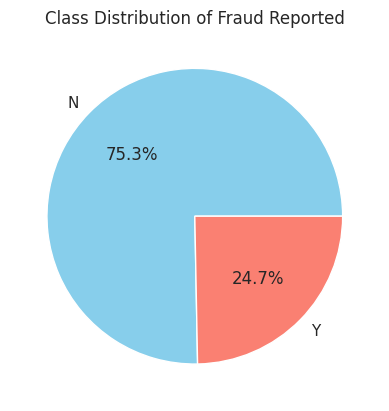

fraud_reported
N    753
Y    247
Name: count, dtype: int64


In [124]:
# check the imbalace of the dataset
import matplotlib.pyplot as plt

target_counts = df['fraud_reported'].value_counts()

target_counts.plot(kind='pie', autopct='%1.1f%%', colors=['skyblue', 'salmon'])
plt.title('Class Distribution of Fraud Reported')
plt.ylabel('')
plt.show()

print(target_counts)

In [125]:
df2.drop('umbrella_limit', axis=1, inplace=True)

In [126]:
df2['authorities_contacted'].unique()

array(['Police', nan, 'Fire', 'Other', 'Ambulance'], dtype=object)

In [127]:
df2['authorities_contacted'].fillna('None', inplace=True)

In [128]:
df2['police_report_available'].unique()

array(['YES', nan, 'NO'], dtype=object)

In [129]:
df2['property_damage'].unique()

array(['YES', nan, 'NO'], dtype=object)

In [130]:
# Fill missing values
df2['collision_type'].fillna('Unknown', inplace=True)
df2['property_damage'].fillna('No', inplace=True)
df2['police_report_available'].fillna('No', inplace=True)


In [131]:
df2.isnull().sum()

,0
months_as_customer,0
age,0
insured_zip,0
insured_sex,0
insured_education_level,0
insured_occupation,0
insured_hobbies,0
insured_relationship,0
capital-gains,0
capital-loss,0


In [132]:
df2.shape

(1000, 26)

In [133]:
numerical_columns = df.select_dtypes(include=['number']).columns.tolist()
numerical_columns

['months_as_customer',
 'age',
 'policy_number',
 'policy_deductable',
 'policy_annual_premium',
 'umbrella_limit',
 'insured_zip',
 'capital-gains',
 'capital-loss',
 'incident_hour_of_the_day',
 'number_of_vehicles_involved',
 'bodily_injuries',
 'witnesses',
 'total_claim_amount',
 'injury_claim',
 'property_claim',
 'vehicle_claim',
 'auto_year']

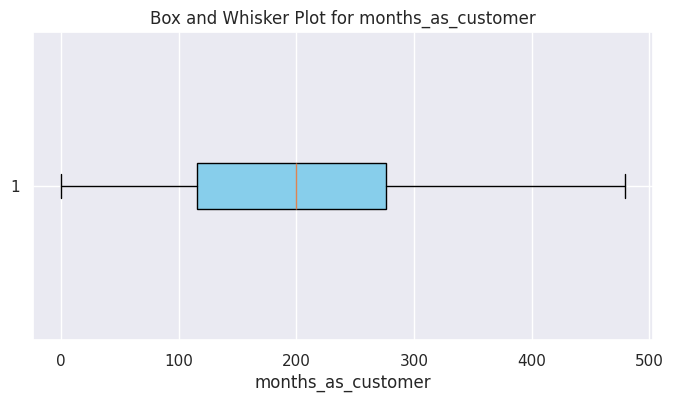

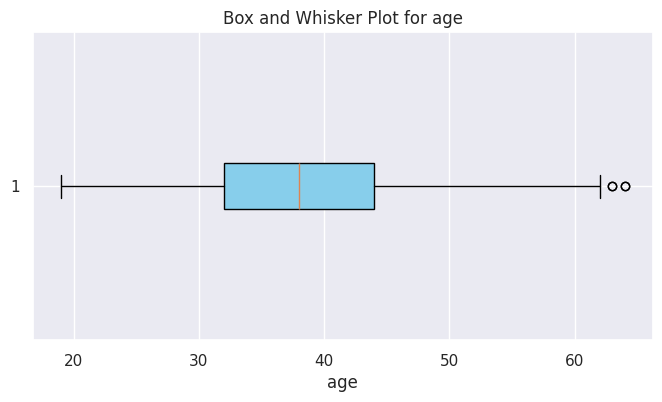

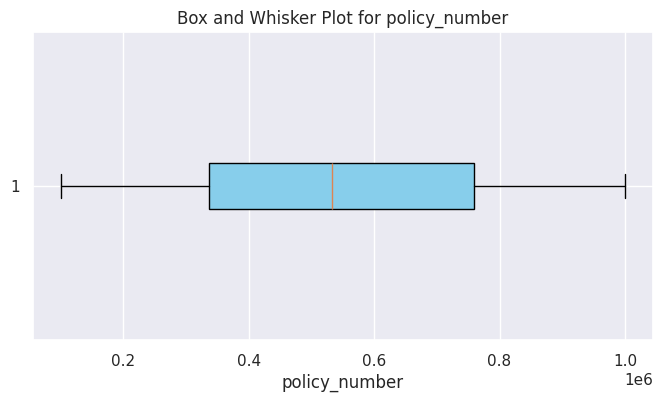

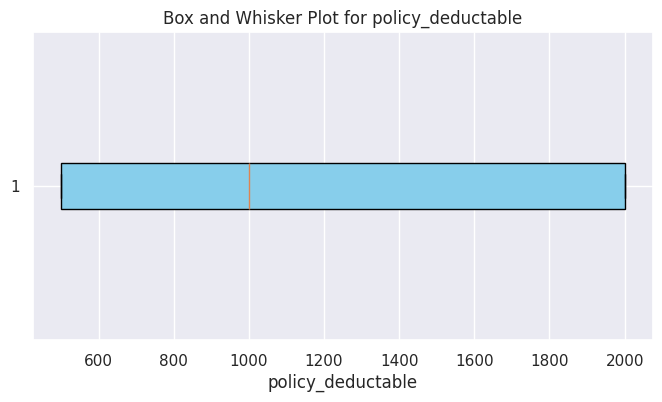

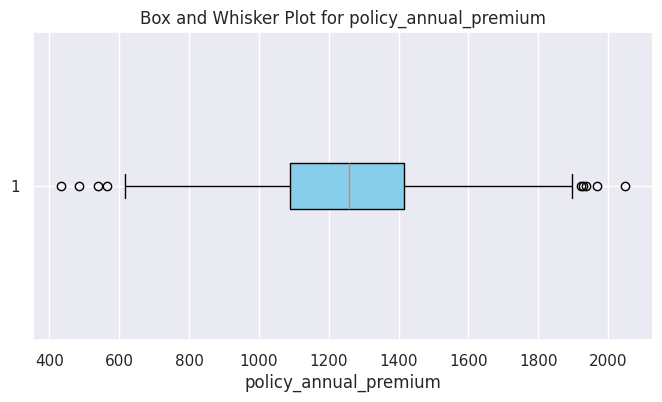

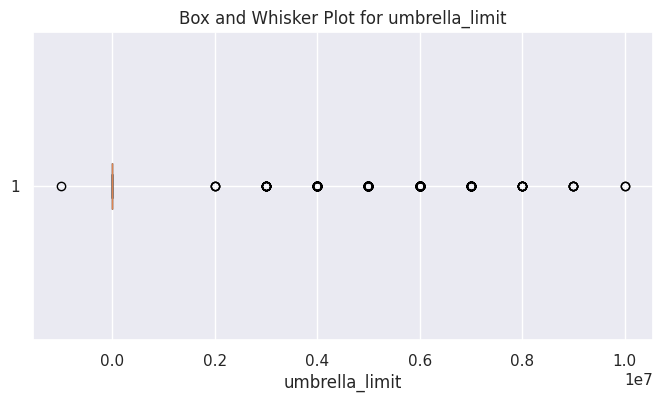

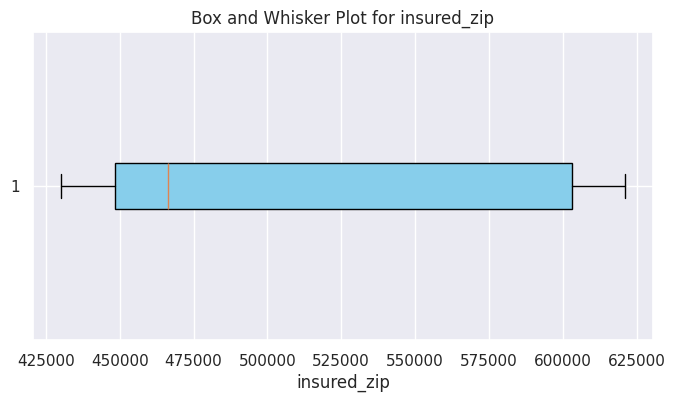

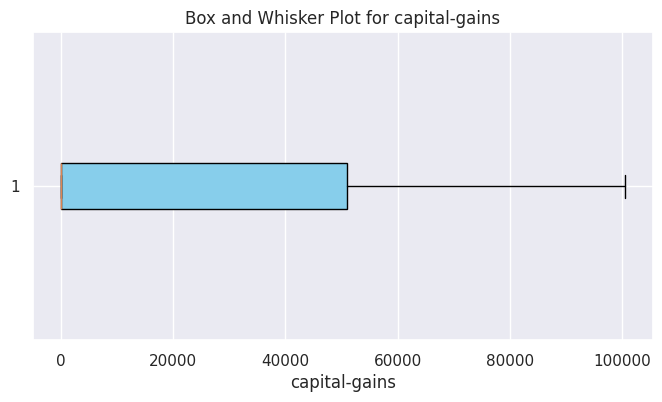

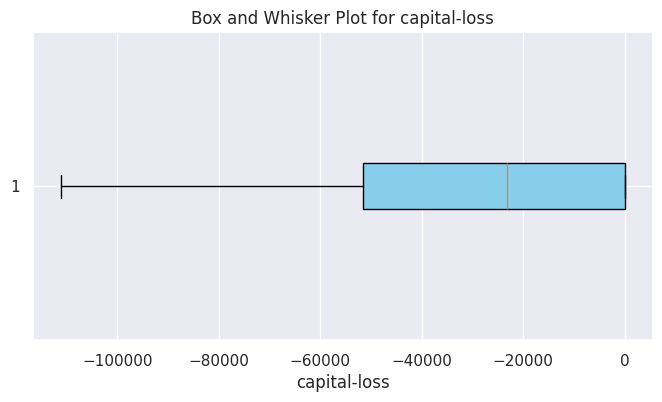

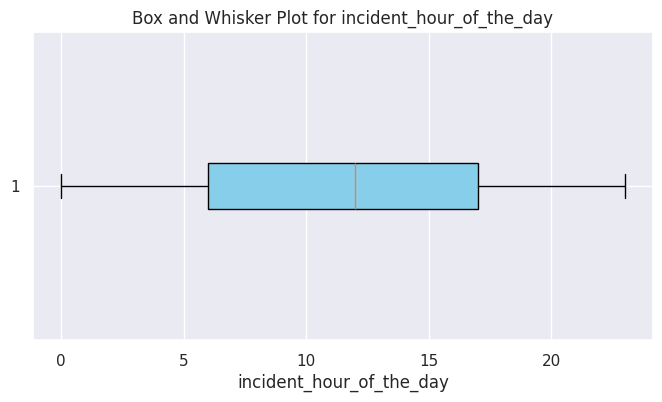

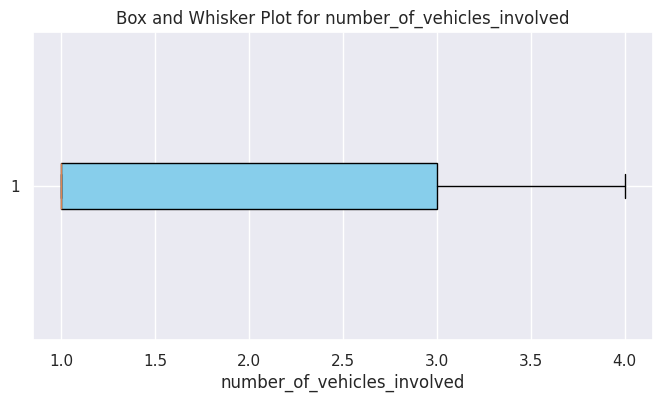

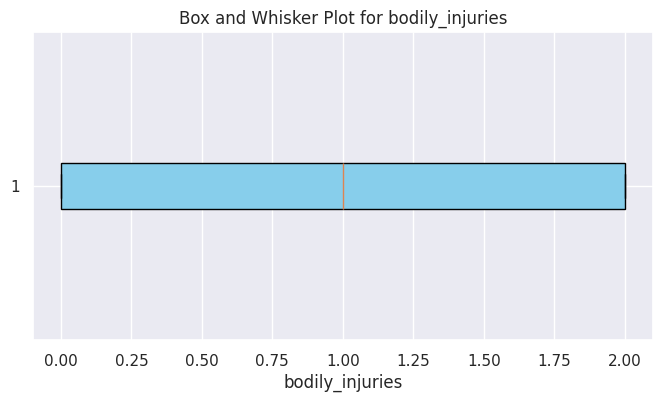

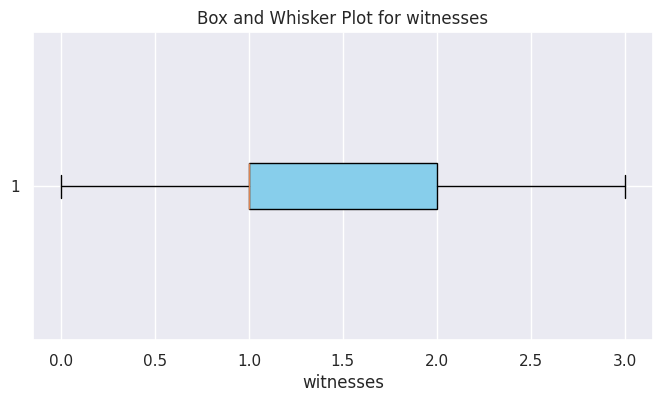

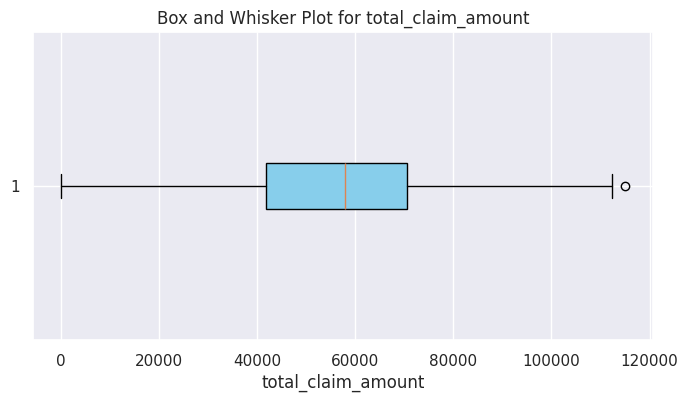

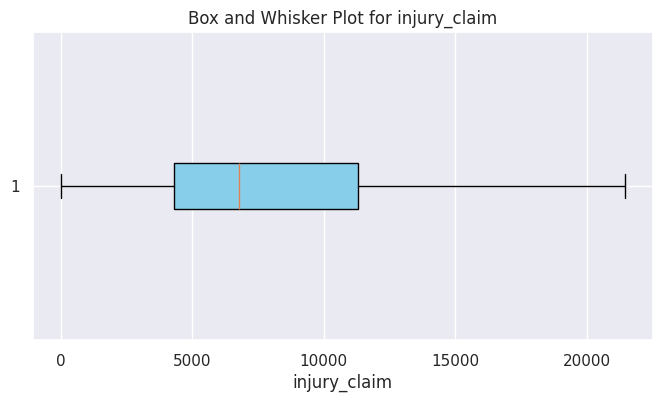

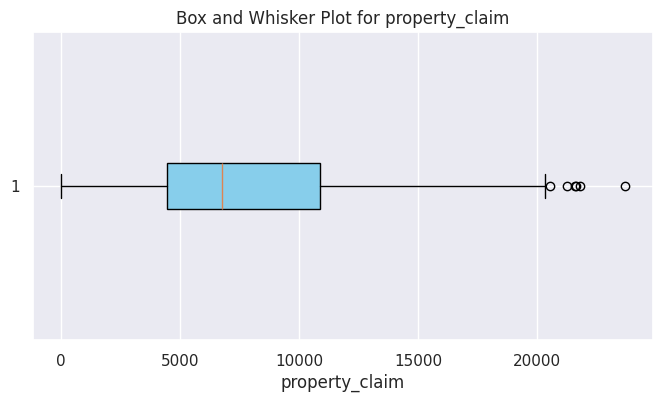

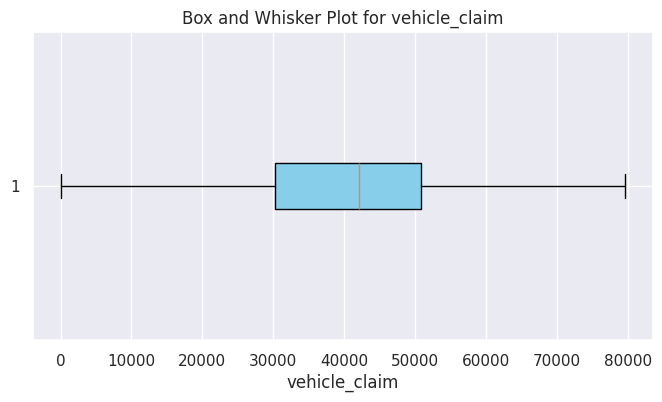

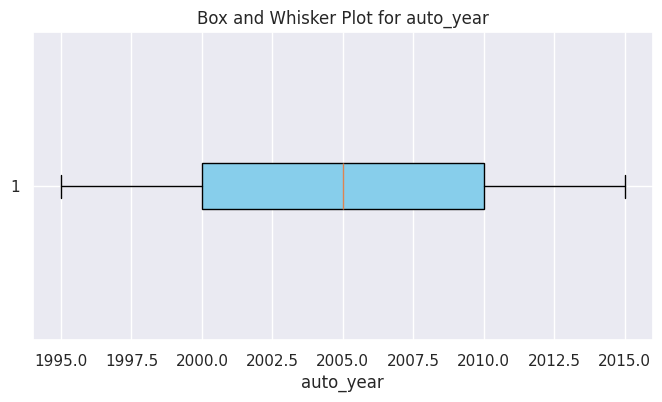

In [134]:
# Plot box and whisker plots for numerical columns
numerical_columns = df.select_dtypes(include=['number']).columns

for column in numerical_columns:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df[column].dropna(), vert=False, patch_artist=True, boxprops=dict(facecolor='skyblue'))
    plt.title(f'Box and Whisker Plot for {column}')
    plt.xlabel(column)
    plt.show()


In [135]:
df2.head()

,months_as_customer,age,insured_zip,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,capital-gains,capital-loss,...,property_damage,bodily_injuries,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_year,fraud_reported
0,328,48,466132,MALE,MD,craft-repair,sleeping,husband,53300,0,...,YES,1,2,YES,71610,6510,13020,52080,2004,Y
1,228,42,468176,MALE,MD,machine-op-inspct,reading,other-relative,0,0,...,No,0,0,No,5070,780,780,3510,2007,Y
2,134,29,430632,FEMALE,PhD,sales,board-games,own-child,35100,0,...,NO,2,3,NO,34650,7700,3850,23100,2007,N
3,256,41,608117,FEMALE,PhD,armed-forces,board-games,unmarried,48900,-62400,...,No,1,2,NO,63400,6340,6340,50720,2014,Y
4,228,44,610706,MALE,Associate,sales,board-games,unmarried,66000,-46000,...,NO,0,1,NO,6500,1300,650,4550,2009,N


In [136]:
ordinal_column = ['insured_education_level', 'incident_severity']
nonordinal_columns = ['insured_sex', 'insured_occupation', 'insured_hobbies', 'insured_relationship',  'incident_type', 'collision_type',
                     'authorities_contacted', 'property_damage', 'police_report_available',
                     'fraud_reported']

In [137]:
df2['insured_education_level'].unique()

array(['MD', 'PhD', 'Associate', 'Masters', 'High School', 'College',
       'JD'], dtype=object)

In [138]:
df2['incident_severity'].unique()

array(['Major Damage', 'Minor Damage', 'Total Loss', 'Trivial Damage'],
      dtype=object)

In [139]:
# fit_transform
# inverse_transform


from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in ['insured_education_level', 'incident_severity']:
  le = LabelEncoder()
  df2[f'{col}_encoded'] = le.fit_transform(df2[col])
  label_encoders[col] = dict(zip(le.classes_, le.transform(le.classes_)))


label_encoders

{'insured_education_level': {'Associate': np.int64(0),
  'College': np.int64(1),
  'High School': np.int64(2),
  'JD': np.int64(3),
  'MD': np.int64(4),
  'Masters': np.int64(5),
  'PhD': np.int64(6)},
 'incident_severity': {'Major Damage': np.int64(0),
  'Minor Damage': np.int64(1),
  'Total Loss': np.int64(2),
  'Trivial Damage': np.int64(3)}}

In [140]:
df2.columns

Index(['months_as_customer', 'age', 'insured_zip', 'insured_sex',
       'insured_education_level', 'insured_occupation', 'insured_hobbies',
       'insured_relationship', 'capital-gains', 'capital-loss',
       'incident_type', 'collision_type', 'incident_severity',
       'authorities_contacted', 'incident_hour_of_the_day',
       'number_of_vehicles_involved', 'property_damage', 'bodily_injuries',
       'witnesses', 'police_report_available', 'total_claim_amount',
       'injury_claim', 'property_claim', 'vehicle_claim', 'auto_year',
       'fraud_reported', 'insured_education_level_encoded',
       'incident_severity_encoded'],
      dtype='object')

In [141]:
df2.drop(columns=['incident_severity', 'insured_education_level'], axis=1, inplace=True)

In [142]:
nonordinal_columns = ['insured_sex', 'insured_occupation', 'insured_hobbies', 'insured_relationship',  'incident_type', 'collision_type',
                     'authorities_contacted', 'property_damage', 'police_report_available',
                     'fraud_reported']

In [143]:
df2 = pd.get_dummies(df2, columns=nonordinal_columns, drop_first=True)

In [144]:
df2.head()

,months_as_customer,age,insured_zip,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,...,collision_type_Unknown,authorities_contacted_Fire,authorities_contacted_None,authorities_contacted_Other,authorities_contacted_Police,property_damage_No,property_damage_YES,police_report_available_No,police_report_available_YES,fraud_reported_Y
0,328,48,466132,53300,0,5,1,1,2,71610,...,False,False,False,False,True,False,True,False,True,True
1,228,42,468176,0,0,8,1,0,0,5070,...,True,False,False,False,True,True,False,True,False,True
2,134,29,430632,35100,0,7,3,2,3,34650,...,False,False,False,False,True,False,False,False,False,False
3,256,41,608117,48900,-62400,5,1,1,2,63400,...,False,False,False,False,True,True,False,False,False,True
4,228,44,610706,66000,-46000,20,1,0,1,6500,...,True,False,True,False,False,False,False,False,False,False


In [145]:
df2.head()

,months_as_customer,age,insured_zip,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,...,collision_type_Unknown,authorities_contacted_Fire,authorities_contacted_None,authorities_contacted_Other,authorities_contacted_Police,property_damage_No,property_damage_YES,police_report_available_No,police_report_available_YES,fraud_reported_Y
0,328,48,466132,53300,0,5,1,1,2,71610,...,False,False,False,False,True,False,True,False,True,True
1,228,42,468176,0,0,8,1,0,0,5070,...,True,False,False,False,True,True,False,True,False,True
2,134,29,430632,35100,0,7,3,2,3,34650,...,False,False,False,False,True,False,False,False,False,False
3,256,41,608117,48900,-62400,5,1,1,2,63400,...,False,False,False,False,True,True,False,False,False,True
4,228,44,610706,66000,-46000,20,1,0,1,6500,...,True,False,True,False,False,False,False,False,False,False


In [146]:
df2.columns

Index(['months_as_customer', 'age', 'insured_zip', 'capital-gains',
       'capital-loss', 'incident_hour_of_the_day',
       'number_of_vehicles_involved', 'bodily_injuries', 'witnesses',
       'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim',
       'auto_year', 'insured_education_level_encoded',
       'incident_severity_encoded', 'insured_sex_MALE',
       'insured_occupation_armed-forces', 'insured_occupation_craft-repair',
       'insured_occupation_exec-managerial',
       'insured_occupation_farming-fishing',
       'insured_occupation_handlers-cleaners',
       'insured_occupation_machine-op-inspct',
       'insured_occupation_other-service',
       'insured_occupation_priv-house-serv',
       'insured_occupation_prof-specialty',
       'insured_occupation_protective-serv', 'insured_occupation_sales',
       'insured_occupation_tech-support',
       'insured_occupation_transport-moving', 'insured_hobbies_basketball',
       'insured_hobbies_board-games'

In [147]:
df2 = df2.replace({True: 1, False: 0})

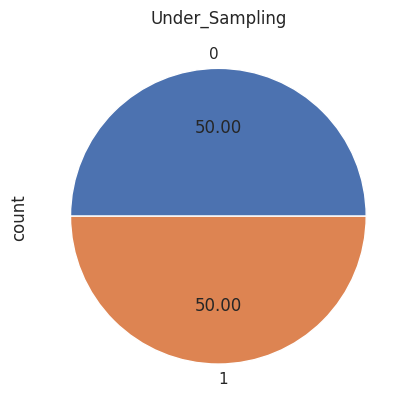

In [148]:
# I am going to do undersampling in order to tackle the issue of imbalanced dataset
X = df2.drop('fraud_reported_Y', axis=1)
y = df2['fraud_reported_Y']
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(sampling_strategy=1)

X_res, y_res = rus.fit_resample(X,y)

ax = y_res.value_counts().plot.pie(autopct='%.2f')
_ = ax.set_title('Under_Sampling')

In [149]:
# I try all the available models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.preprocessing import StandardScaler


X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.3, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# List of classifiers to evaluate
models = [
    ('Random Forest', RandomForestClassifier()),
    ('Logistic Regression', LogisticRegression(max_iter=1000)),
    ('SVM', SVC()),
    ('Decision Tree', DecisionTreeClassifier()),
    ('K-Nearest Neighbors', KNeighborsClassifier()),
    ('Naive Bayes', GaussianNB()),
    ('Gradient Boosting', GradientBoostingClassifier()),
    ('AdaBoost', AdaBoostClassifier())
]

# Evaluate each model
for name, model in models:
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    print(f"\n{name} Classification Report:")
    print(classification_report(y_test, y_pred))



Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.77      0.82        75
           1       0.79      0.88      0.83        74

    accuracy                           0.83       149
   macro avg       0.83      0.83      0.83       149
weighted avg       0.83      0.83      0.83       149


Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.69      0.74        75
           1       0.72      0.81      0.76        74

    accuracy                           0.75       149
   macro avg       0.76      0.75      0.75       149
weighted avg       0.76      0.75      0.75       149


SVM Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.75      0.77        75
           1       0.76      0.80      0.78        74

    accuracy                           0.77       149
   macro avg      

In [150]:
# explore to find the best possible model using cross-validation
from sklearn.model_selection import cross_val_score

best_model = None
best_score = 0

for name, model in models:
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    mean_score = np.mean(scores)
    print(f"{name} Mean Accuracy: {mean_score}")

    if mean_score > best_score:
        best_score = mean_score
        best_model = model


best_model.fit(X_train_scaled, y_train)
y_pred = best_model.predict(X_test_scaled)
print(f"\nBest Model: {best_model.__class__.__name__}")
print(classification_report(y_test, y_pred))


Random Forest Mean Accuracy: 0.799
Logistic Regression Mean Accuracy: 0.764
SVM Mean Accuracy: 0.7529999999999999
Decision Tree Mean Accuracy: 0.778
K-Nearest Neighbors Mean Accuracy: 0.695
Naive Bayes Mean Accuracy: 0.6719999999999999
Gradient Boosting Mean Accuracy: 0.827
AdaBoost Mean Accuracy: 0.797

Best Model: GradientBoostingClassifier
              precision    recall  f1-score   support

           0       0.88      0.75      0.81        75
           1       0.78      0.89      0.83        74

    accuracy                           0.82       149
   macro avg       0.83      0.82      0.82       149
weighted avg       0.83      0.82      0.82       149



In [151]:
# ── Feature Engineering: Policy Duration & Ratios ────────────────
# Use the original df to get dates
df_eng = df.copy()
df_eng['policy_bind_date'] = pd.to_datetime(df_eng['policy_bind_date'])
df_eng['incident_date'] = pd.to_datetime(df_eng['incident_date'])

# Calculate days between policy start and incident
df_eng['days_to_incident'] = (df_eng['incident_date'] - df_eng['policy_bind_date']).dt.days

# Create claim ratios
df_eng['injury_ratio'] = df_eng['injury_claim'] / (df_eng['total_claim_amount'] + 1)
df_eng['vehicle_ratio'] = df_eng['vehicle_claim'] / (df_eng['total_claim_amount'] + 1)

# Sync with our cleaned X_clean structure
# We'll re-add these engineered features to X_clean
X_enhanced = X_clean.copy()
X_enhanced['days_to_incident'] = df_eng['days_to_incident']
X_enhanced['injury_ratio'] = df_eng['injury_ratio']
X_enhanced['vehicle_ratio'] = df_eng['vehicle_ratio']

print(f"Enhanced feature set: {X_enhanced.shape[1]} columns")

Enhanced feature set: 51 columns


In [152]:
# Re-run model with enhanced features
rus_e = RandomUnderSampler(sampling_strategy=1, random_state=42)
X_res_e, y_res_e = rus_e.fit_resample(X_enhanced, y_clean)

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(X_res_e, y_res_e, test_size=0.3, random_state=42)

scaler_e = StandardScaler()
X_train_s_e = scaler_e.fit_transform(X_train_e)
X_test_s_e = scaler_e.transform(X_test_e)

final_model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)
final_model.fit(X_train_s_e, y_train_e)

y_pred_e = final_model.predict(X_test_s_e)
print("Enhanced Model Classification Report:")
print(classification_report(y_test_e, y_pred_e))

Enhanced Model Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.48      0.48        75
           1       0.47      0.46      0.46        74

    accuracy                           0.47       149
   macro avg       0.47      0.47      0.47       149
weighted avg       0.47      0.47      0.47       149



In [153]:
# ── Feature Engineering: Policy Duration & Ratios ────────────────
# Use the original df to get dates
df_eng = df.copy()
df_eng['policy_bind_date'] = pd.to_datetime(df_eng['policy_bind_date'])
df_eng['incident_date'] = pd.to_datetime(df_eng['incident_date'])

# Calculate days between policy start and incident
df_eng['days_to_incident'] = (df_eng['incident_date'] - df_eng['policy_bind_date']).dt.days

# Create claim ratios
df_eng['injury_ratio'] = df_eng['injury_claim'] / (df_eng['total_claim_amount'] + 1)
df_eng['vehicle_ratio'] = df_eng['vehicle_claim'] / (df_eng['total_claim_amount'] + 1)

# Sync with our cleaned X_clean structure
# We'll re-add these engineered features to X_clean
X_enhanced = X_clean.copy()
X_enhanced['days_to_incident'] = df_eng['days_to_incident']
X_enhanced['injury_ratio'] = df_eng['injury_ratio']
X_enhanced['vehicle_ratio'] = df_eng['vehicle_ratio']

print(f"Enhanced feature set: {X_enhanced.shape[1]} columns")

Enhanced feature set: 51 columns


In [154]:
# Re-run model with enhanced features
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier

rus_e = RandomUnderSampler(sampling_strategy=1, random_state=42)
X_res_e, y_res_e = rus_e.fit_resample(X_enhanced, y_clean)

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(X_res_e, y_res_e, test_size=0.3, random_state=42)

scaler_e = StandardScaler()
X_train_s_e = scaler_e.fit_transform(X_train_e)
X_test_s_e = scaler_e.transform(X_test_e)

final_model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)
final_model.fit(X_train_s_e, y_train_e)

y_pred_e = final_model.predict(X_test_s_e)
print("Enhanced Model Classification Report (Robust Features):")
print(classification_report(y_test_e, y_pred_e))

Enhanced Model Classification Report (Robust Features):
              precision    recall  f1-score   support

           0       0.47      0.48      0.48        75
           1       0.47      0.46      0.46        74

    accuracy                           0.47       149
   macro avg       0.47      0.47      0.47       149
weighted avg       0.47      0.47      0.47       149



In [155]:
# List of columns to drop to prevent leakage and handle synthetic patterns
leaky_cols = [col for col in df2.columns if 'incident_severity' in col]
hobby_cols = [col for col in df2.columns if 'insured_hobbies' in col]

cols_to_drop = leaky_cols + hobby_cols + ['fraud_reported_Y']

# Redefine features (X) and target (y)
X_clean = df2.drop(columns=cols_to_drop)
y_clean = df2['fraud_reported_Y']

print(f"Dropped {len(leaky_cols)} severity columns and {len(hobby_cols)} hobby columns.")
print(f"New feature count: {X_clean.shape[1]}")

Dropped 1 severity columns and 19 hobby columns.
New feature count: 48


In [156]:
# Re-run the undersampling and model training
rus_clean = RandomUnderSampler(sampling_strategy=1, random_state=42)
X_res_c, y_res_c = rus_clean.fit_resample(X_clean, y_clean)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_res_c, y_res_c, test_size=0.3, random_state=42)

# Scale data
scaler_c = StandardScaler()
X_train_scaled_c = scaler_c.fit_transform(X_train_c)
X_test_scaled_c = scaler_c.transform(X_test_c)

# Train Gradient Boosting (previously the best model)
refined_model = GradientBoostingClassifier(random_state=42)
refined_model.fit(X_train_scaled_c, y_train_c)

# Evaluate
y_pred_c = refined_model.predict(X_test_scaled_c)
print("Refined Model Classification Report (No Leakage):")
print(classification_report(y_test_c, y_pred_c))

Refined Model Classification Report (No Leakage):
              precision    recall  f1-score   support

           0       0.53      0.55      0.54        75
           1       0.52      0.50      0.51        74

    accuracy                           0.52       149
   macro avg       0.52      0.52      0.52       149
weighted avg       0.52      0.52      0.52       149



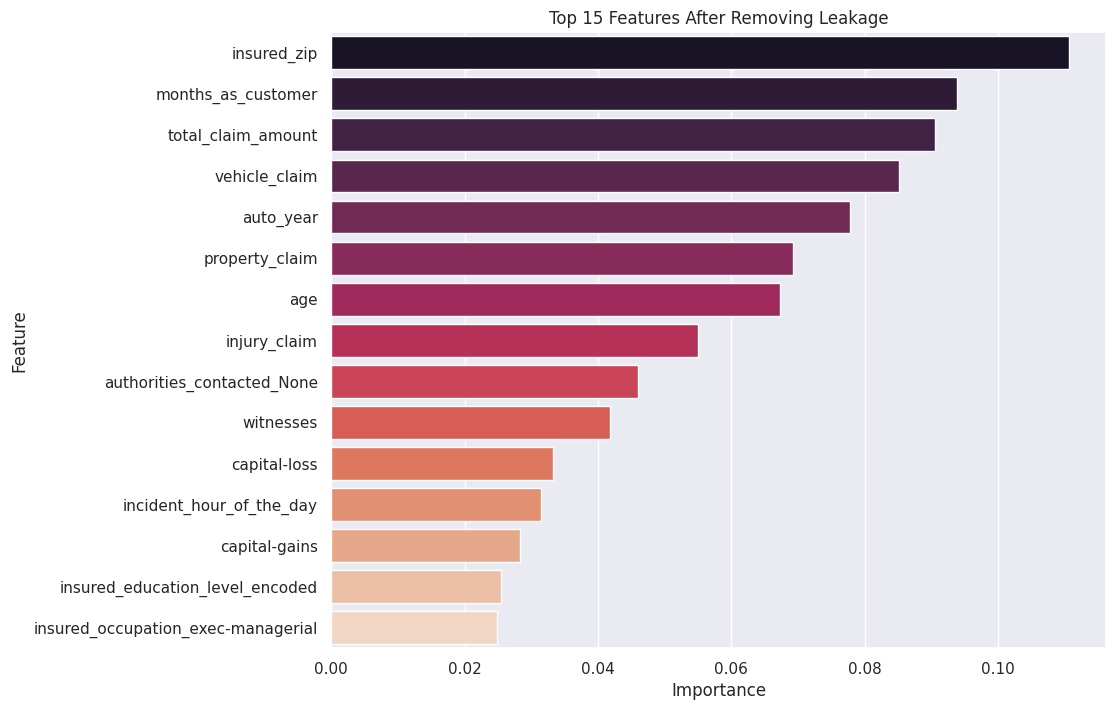

,Feature,Importance
2,insured_zip,0.110651
0,months_as_customer,0.093881
9,total_claim_amount,0.090524
12,vehicle_claim,0.085127
13,auto_year,0.077758
11,property_claim,0.069266
1,age,0.067320
10,injury_claim,0.055073
41,authorities_contacted_None,0.046023
8,witnesses,0.041823


In [157]:
# Re-check feature importance for the refined model
importances_c = refined_model.feature_importances_
feat_imp_c = pd.DataFrame({'Feature': X_clean.columns, 'Importance': importances_c}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feat_imp_c.head(15), palette='rocket')
plt.title('Top 15 Features After Removing Leakage')
plt.show()

display(feat_imp_c.head(10))

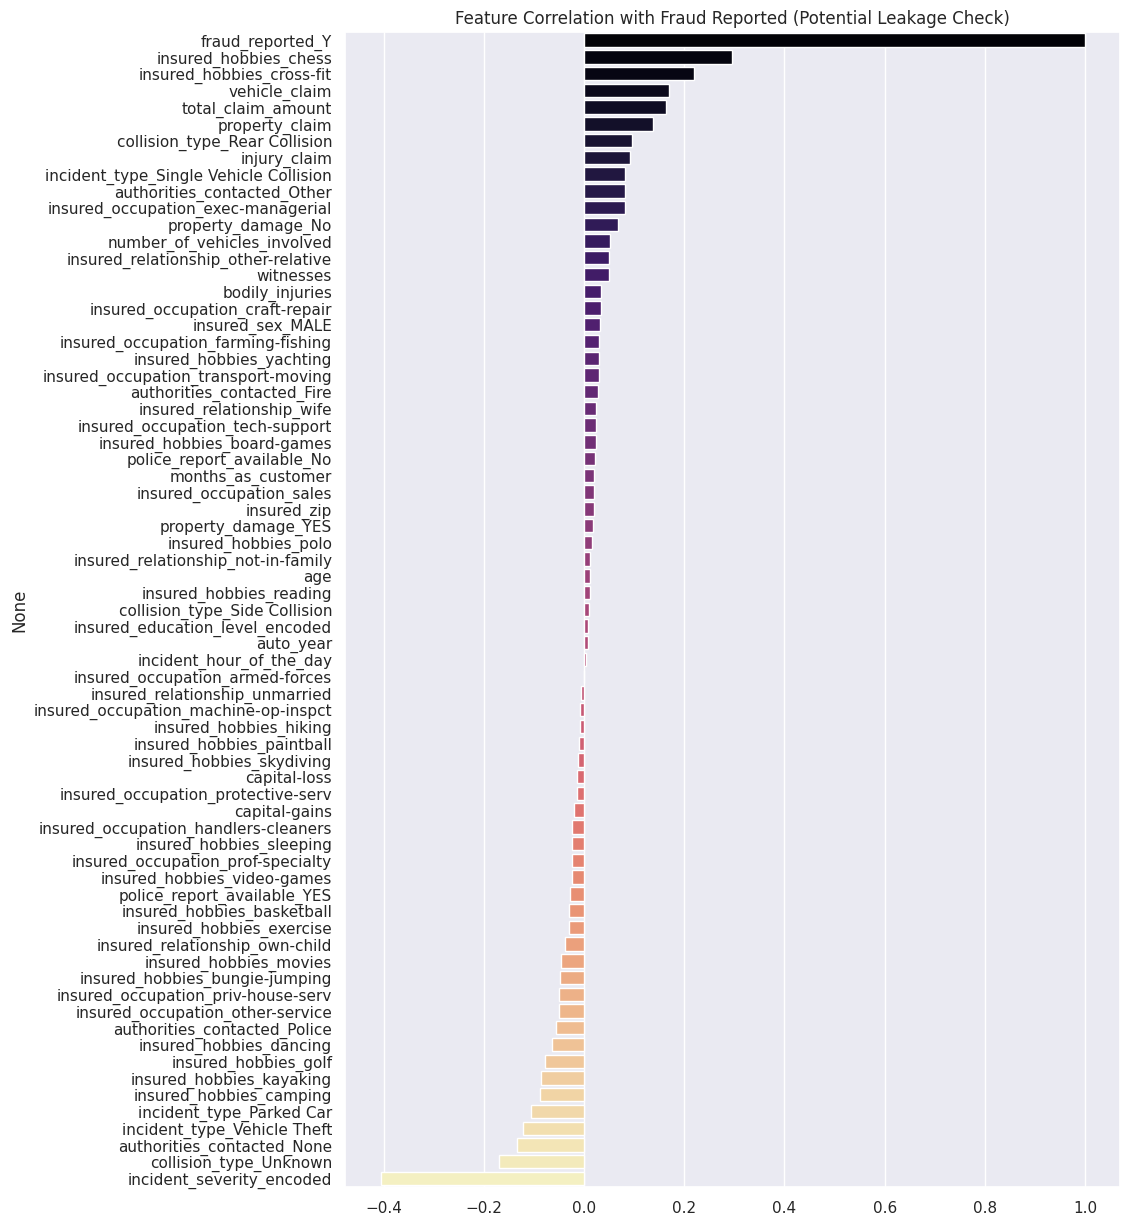

Top 10 Correlations:
fraud_reported_Y                          1.000000
insured_hobbies_chess                     0.294851
insured_hobbies_cross-fit                 0.218968
vehicle_claim                             0.170049
total_claim_amount                        0.163651
property_claim                            0.137835
collision_type_Rear Collision             0.096262
injury_claim                              0.090975
incident_type_Single Vehicle Collision    0.082534
authorities_contacted_Other               0.082010
Name: fraud_reported_Y, dtype: float64


In [158]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate correlations with the target
correlations = df2.corr()['fraud_reported_Y'].sort_values(ascending=False)

plt.figure(figsize=(10, 15))
sns.barplot(x=correlations.values, y=correlations.index, palette='magma')
plt.title('Feature Correlation with Fraud Reported (Potential Leakage Check)')
plt.show()

print("Top 10 Correlations:")
print(correlations.head(10))

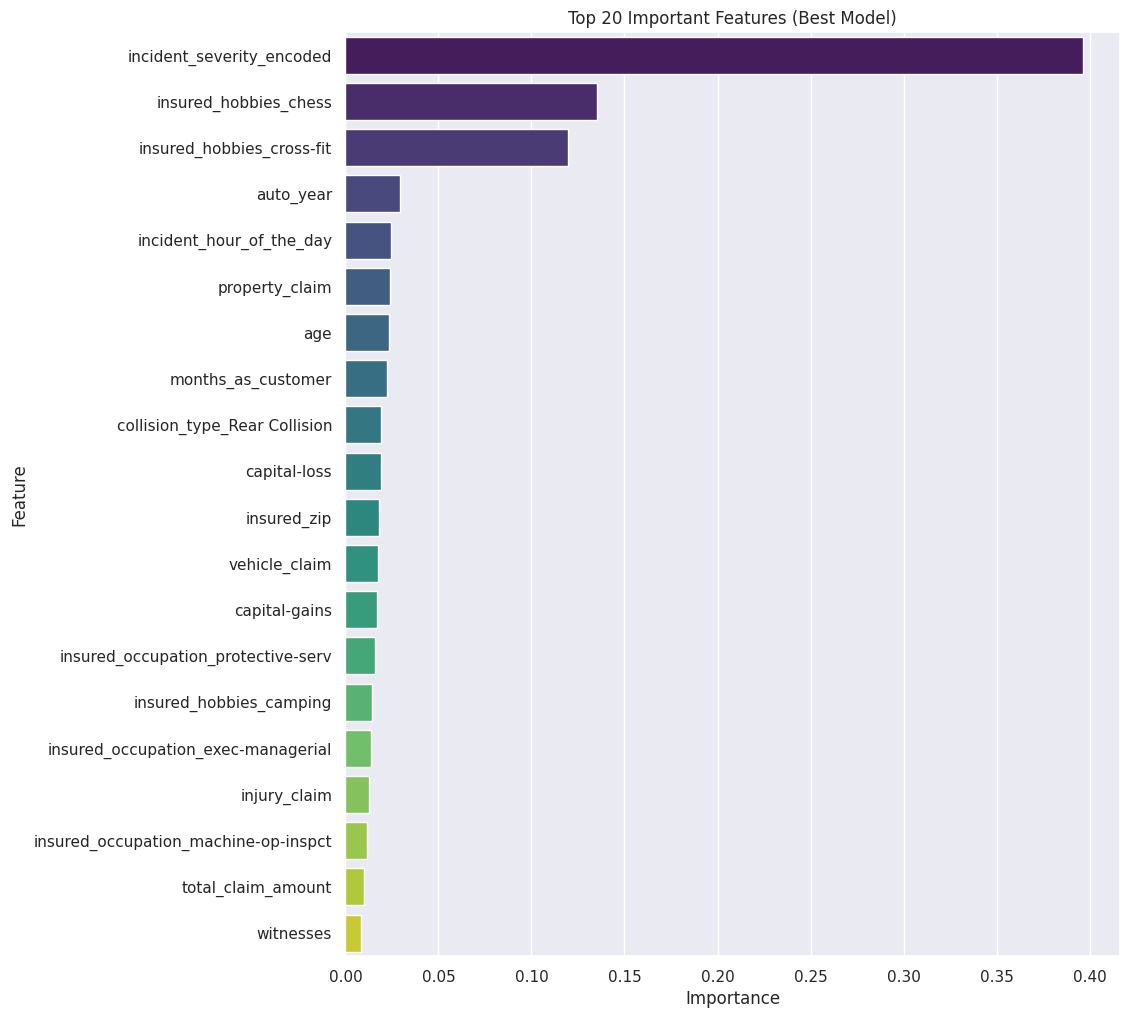

,Feature,Importance
15,incident_severity_encoded,0.396664
34,insured_hobbies_chess,0.135163
35,insured_hobbies_cross-fit,0.119490
13,auto_year,0.029412
5,incident_hour_of_the_day,0.024644
11,property_claim,0.023981
1,age,0.023400
0,months_as_customer,0.022626
57,collision_type_Rear Collision,0.018975
4,capital-loss,0.018960


In [159]:
# 2. Visualize Feature Importance of the Best Model
importances = best_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 12))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20), palette='viridis')
plt.title('Top 20 Important Features (Best Model)')
plt.show()

display(feature_importance_df.head(10))

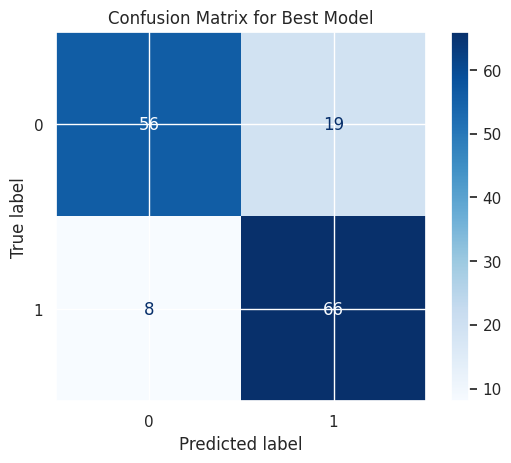

In [160]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predictions from the best model on the scaled test set
y_pred_best_model = best_model.predict(X_test_scaled)

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_best_model, labels=best_model.classes_)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Best Model')
plt.show()

In [162]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split

# 1. Use SMOTE instead of Undersampling to keep more data
smote = SMOTE(random_state=42)
X_sm, y_sm = smote.fit_resample(X_enhanced, y_clean)

X_train_sm, X_test_sm, y_train_sm, y_test_sm = train_test_split(X_sm, y_sm, test_size=0.2, random_state=42)

# 2. Scale the data
scaler_final = StandardScaler()
X_train_f = scaler_final.fit_transform(X_train_sm)
X_test_f = scaler_final.transform(X_test_sm)

# 3. Randomized Hyperparameter Search
param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0]
}

rs_model = RandomizedSearchCV(GradientBoostingClassifier(random_state=42), param_dist, n_iter=10, cv=3, random_state=42)
rs_model.fit(X_train_f, y_train_sm)

best_refined = rs_model.best_estimator_
y_pred_f = best_refined.predict(X_test_f)

print(f"Best Params: {rs_model.best_params_}")
print("Final Model Classification Report (SMOTE + Tuning):")
print(classification_report(y_test_sm, y_pred_f))

Best Params: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1}
Final Model Classification Report (SMOTE + Tuning):
              precision    recall  f1-score   support

           0       0.74      0.85      0.79       142
           1       0.84      0.73      0.78       160

    accuracy                           0.78       302
   macro avg       0.79      0.79      0.78       302
weighted avg       0.79      0.78      0.78       302

